# Import

In [19]:
import numpy as np
import pandas as pd # type: ignore
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from rbf_main import RBF, one_hot, set_seed, rbf_classification_training, confusion_matrix

## Separation du dataSet

In [20]:
np.random.seed(12)
NB_IMG_PER_CLASSES = 1000

base = Path("data")
classes = ["compost", "dechets_chimiques", "recyclable"]

rows = []
for cls in classes:
    images = sorted((base / cls).glob("*.jpg"))[:NB_IMG_PER_CLASSES]
    for img_path in images:
        rows.append({
            "path": str(img_path),
            "nom_image": img_path.name,
            "classe": cls
        })

df = pd.DataFrame(rows)

def assign_split(n, ratios=(0.70, 0.28, 0.02)):
    labels = np.array(["train"] * n)
    idx = np.random.permutation(n)
    t1 = int(n * ratios[0])
    t2 = int(n * (ratios[0] + ratios[1]))
    labels[idx[t1:t2]] = "val"
    labels[idx[t2:]] = "test"
    return labels

df["cat"] = df.groupby("classe")["path"].transform(lambda x: assign_split(len(x)))

print(f"Total : {len(df)} images")
print(df.groupby("classe")["cat"].value_counts())
df.head()

Total : 3000 images
classe             cat  
compost            train    700
                   val      280
                   test      20
dechets_chimiques  train    700
                   val      280
                   test      20
recyclable         train    700
                   val      280
                   test      20
Name: count, dtype: int64


,path,nom_image,classe,cat
0,data\compost\compost_0001.jpg,compost_0001.jpg,compost,train
1,data\compost\compost_0002.jpg,compost_0002.jpg,compost,train
2,data\compost\compost_0003.jpg,compost_0003.jpg,compost,val
3,data\compost\compost_0004.jpg,compost_0004.jpg,compost,train
4,data\compost\compost_0005.jpg,compost_0005.jpg,compost,train


## Transformation des données (redimension + gray lvl)

In [21]:
IMG = 24
IMG_SIZE = (IMG, IMG)

def load_image(path):
    try:
        img = Image.open(path).convert("L")
        img = img.resize(IMG_SIZE)
        return np.array(img, dtype=np.float32).flatten() / 255.0
    except (OSError, IOError):
        return None

df["pixels"] = [load_image(p) for p in tqdm(df["path"], desc="Chargement")]

n_before = len(df)
df = df.dropna(subset=["pixels"]).reset_index(drop=True)
print(f"Images corrompues supprimées : {n_before - len(df)}")

X_train = np.stack(df[df["cat"] == "train"]["pixels"].values)
X_val   = np.stack(df[df["cat"] == "val"]["pixels"].values)
X_test  = np.stack(df[df["cat"] == "test"]["pixels"].values)

label_map = {cls: i for i, cls in enumerate(classes)}
y_train = df[df["cat"] == "train"]["classe"].map(label_map).values
y_val   = df[df["cat"] == "val"]["classe"].map(label_map).values
y_test  = df[df["cat"] == "test"]["classe"].map(label_map).values

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Labels:  {label_map}")

Chargement: 100%|██████████| 3000/3000 [00:24<00:00, 123.08it/s]

Images corrompues supprimées : 0
X_train: (2100, 576)  y_train: (2100,)
X_val:   (840, 576)    y_val:   (840,)
X_test:  (60, 576)   y_test:  (60,)
Labels:  {'compost': 0, 'dechets_chimiques': 1, 'recyclable': 2}


In [22]:
# Xp - A - Identification du nombre de centre optimaux - 24*24 | Grey Scale

In [ ]:
nb_epoch = 100
seeds_list = [
    [6, 8, 12, 48, 75]
    ,[1, 5, 142, 24, 12]
    ,[3, 8, 9]
]

gammas = [0.01, 0.1, 0.5, 0.8, 2] #0.5 -> le meilleurs
list_nb_centre = np.arange(1500, 2000, 100)
loss_train_final_par_nb_centre, loss_val_final_par_nb_centre, acc_final_par_nb_centre = [], [], []

for c in list_nb_centre :
    print(f"Batch nb_centre -> {c}")

    training_output = rbf_classification_training(
            nb_epoch=nb_epoch
            ,learning_rate=.1
            ,nb_centre=c
            ,gamma=.5
            ,seeds=seeds_list[2]
            ,X_train=X_train, X_val=X_val
            ,y_train=y_train, y_val=y_val
            )

    model               = training_output["model"]
    train_loss_mean     = training_output["train_loss_mean"]
    train_loss_std      = training_output["train_loss_std"]
    val_loss_mean       = training_output["val_loss_mean"]
    val_loss_std        = training_output["val_loss_std"]
    accs_mean           = training_output["accs_mean"]
    accs_std            = training_output["accs_std"]

    # pour plot
    loss_train_final_par_nb_centre.append(train_loss_mean[-1])
    loss_val_final_par_nb_centre.append(val_loss_mean[-1])
    acc_final_par_nb_centre.append(accs_mean[-1])

    # PLOT
    epochs = np.arange(nb_epoch)

    # LOSSES
    plt.figure(00)
    plt.figure(figsize=(20, 6))
    plt.plot(epochs, train_loss_mean, label=f"Moyenne Train Losses - k={c}")
    #plt.fill_between(epochs, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.3, label="Ecart-type Train Losses")

    plt.plot(epochs, val_loss_mean, label=f"Moyenne Validation Losses - k={c}")
    #plt.fill_between(epochs, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.3, label="Ecart-type Validation Losses")

    plt.xlabel("epoch"); plt.ylabel("Losses_Mean")
    plt.title("Moyenne de l'erreur au cours des epoch"); plt.legend()

    # ACCURACY
    plt.figure(10)
    plt.figure(figsize=(20, 6))
    plt.plot(epochs, accs_mean, label=f"Moyenne d'accuracy - k={c}")
    plt.fill_between(epochs, accs_mean - accs_std, accs_mean + accs_std, alpha=0.3, label="Ecart-type")
    plt.xlabel("epoch"); plt.ylabel("Accuracy_Mean")
    plt.title("Accuracy validation"); plt.legend(); plt.grid(True)

Batch nb_centre -> 1500


seed=9: 100%|██████████| 100/100 [07:17<00:00,  4.38s/it, acc=0.537, train=0.0743, val=0.2917]


Batch nb_centre -> 1600


seed=9: 100%|██████████| 100/100 [07:47<00:00,  4.68s/it, acc=0.539, train=0.0568, val=0.2906]


Batch nb_centre -> 1700


seed=8: 100%|██████████| 100/100 [08:09<00:00,  4.90s/it, acc=0.543, train=0.0387, val=0.2869]


[[ 85  54 141]
 [ 68 144  68]
 [ 63  57 160]]


<Figure size 640x480 with 0 Axes>

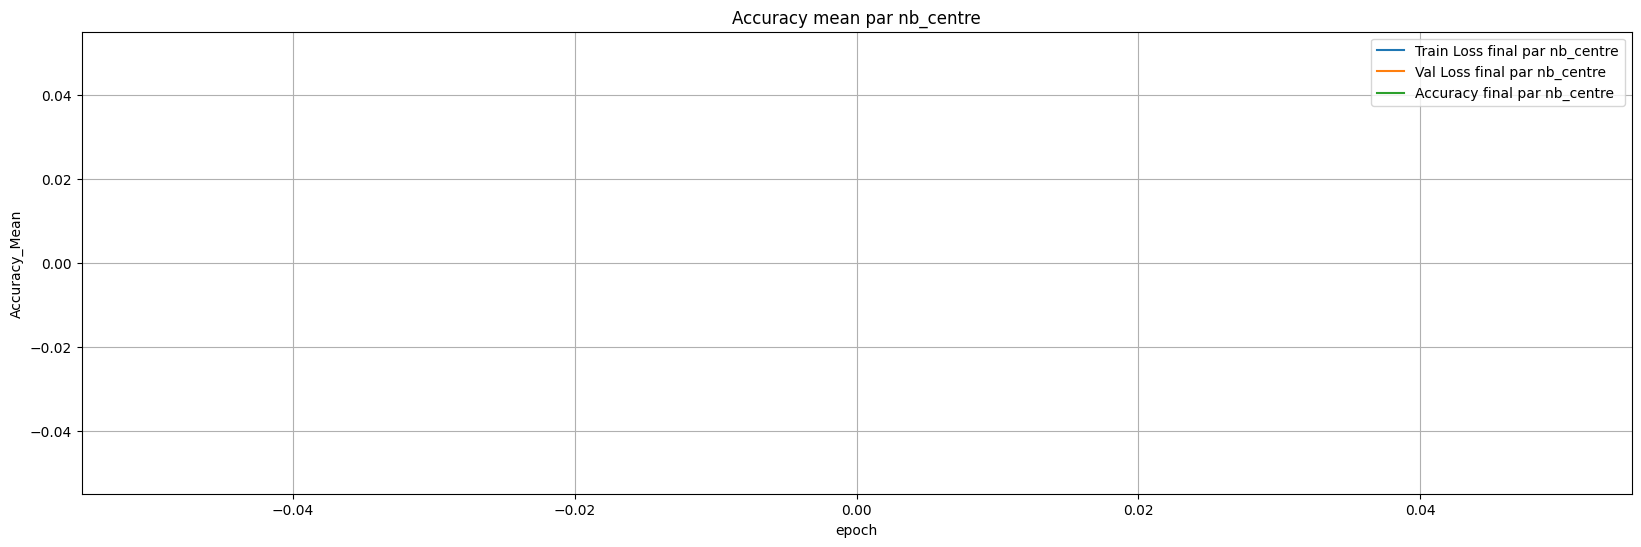

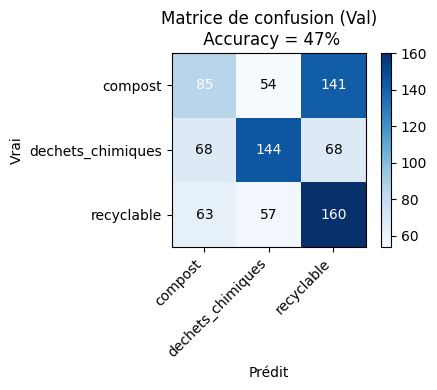

In [27]:
# Courbes par batch
plt.figure(20)
plt.figure(figsize=(20, 6))
plt.plot(list_nb_centre, loss_train_final_par_nb_centre, label="Train Loss final par nb_centre")
plt.plot(list_nb_centre, loss_val_final_par_nb_centre, label="Val Loss final par nb_centre")
plt.xlabel("epoch"); plt.ylabel("Losses_Mean")
plt.title("Loss mean par nb_centre"); plt.legend(); plt.grid(True)

plt.figure(21)
plt.plot(list_nb_centre, acc_final_par_nb_centre, label="Accuracy final par nb_centre")
plt.xlabel("epoch"); plt.ylabel("Accuracy_Mean")
plt.title("Accuracy mean par nb_centre"); plt.legend(); plt.grid(True)

# CM
y_pred = model.predict(X_val)
cm     = confusion_matrix(y_val, y_pred, 3)
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels(classes)
ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai")
ax.set_title(f"Matrice de confusion (Val)\n Accuracy = {accs_mean[-1]*100:.0f}%")
thresh = cm.max() / 2
for i in range(3):
    for j in range(3):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im); plt.tight_layout()

plt.show()
